# Move the camera with the arm

This notebook follows the same Interbotix setup style as `Arm_Control.ipynb`.

It initializes the WidowX arm and then moves the end effector around a circle in the XY plane.

Before running the cells:
- Start the robot controller or the simulation.
- Make sure the `interbotix_ws` environment has been sourced before launching the notebook kernel.


In [2]:
import sys
sys.path.append("..")
from exp_run_config import Config
Config.PROJECTNAME = "BerryPicker"

import time

import matplotlib.pyplot as plt
from interbotix_common_modules.common_robot.robot import robot_shutdown, robot_startup
from interbotix_xs_modules.xs_robot.arm import InterbotixManipulatorXS
# from arm_paths import move_ee_in_circle
from observation_dome import ObservationDome
from widowx_observation_dome import WidowX_ObservationDomeDriver



In [3]:
bot = InterbotixManipulatorXS(
    robot_model='wx250s',
    group_name='arm',
    gripper_name='gripper',
)

robot_startup()


[INFO] [1777213095.644378486] [interbotix_robot_manipulation]: Initialized InterbotixRobotNode!
[INFO] [1777213095.945236428] [interbotix_robot_manipulation]: 
	Robot Name: wx250s
	Robot Model: wx250s
[INFO] [1777213095.946124266] [interbotix_robot_manipulation]: Initialized InterbotixRobotXSCore!
[INFO] [1777213095.959243058] [interbotix_robot_manipulation]: 
	Arm Group Name: arm
	Moving Time: 2.00 seconds
	Acceleration Time: 0.30 seconds
	Drive Mode: Time-Based-Profile
[INFO] [1777213095.959814936] [interbotix_robot_manipulation]: Initialized InterbotixArmXSInterface!
[INFO] [1777213096.462672455] [interbotix_robot_manipulation]: 
	Gripper Name: gripper
	Gripper Pressure: 50.0%
[INFO] [1777213096.463876825] [interbotix_robot_manipulation]: Initialized InterbotixGripperXSInterface!


## Move the camera over an observation dome

Move the camera over all the elements of the observation dome. Simulate the movement first, and only try physically if it succeeds. 

In [4]:
# dome = ObservationDome(x=0.25, y=0.0, z=0.20, r=0.05, no_long=10, no_lat=10)
dome = ObservationDome(x=0.25, y=0.0, z=0.20, r=0.05, no_long=10, no_lat=10)
dome_driver = WidowX_ObservationDomeDriver(bot.arm, dome)

RESET_MODE = 'reset-if-needed'
RESET_POSITION = 'sleep'
MOVE_TIME = 1.5
RESET_MOVE_TIME = 1.5

if RESET_MODE not in {
    'reset-after-every-position',
    'reset-if-needed',
    'do-no-reset',
}:
    raise ValueError(f'Unsupported RESET_MODE: {RESET_MODE}')


successfully_reached = 0
unreachable = 0
total_positions = 0

for lat_index in range(dome.no_lat + 1):
    long_indices = [0] if lat_index == 0 else range(dome.no_long)
    for long_index in long_indices:
        total_positions += 1

        if RESET_MODE == 'reset-after-every-position':
            dome_driver.go_to_reset_position(
                reset_position=RESET_POSITION,
                moving_time=RESET_MOVE_TIME,
            )

        success, command_pose, status = dome_driver.try_move_to_lat_long(
            lat_index,
            long_index,
            moving_time=MOVE_TIME,
        )

        if not success and RESET_MODE == 'reset-if-needed':
            print(
                'Initial attempt failed; resetting and retrying '
                f"lat={lat_index}, long={long_index}, pose={command_pose}, status={status}"
            )
            dome_driver.go_to_reset_position(
                reset_position=RESET_POSITION,
                moving_time=RESET_MOVE_TIME,
            )
            success, command_pose, status = dome_driver.try_move_to_lat_long(
                lat_index,
                long_index,
                moving_time=MOVE_TIME,
            )

        if success:
            successfully_reached += 1
            print(
                'Reached dome node '
                f"lat={lat_index}, long={long_index}, pose={command_pose}, "
                f"count={successfully_reached}/{total_positions}"
            )
        else:
            unreachable += 1
            print(
                'Skipping unreachable dome node '
                f"lat={lat_index}, long={long_index}, pose={command_pose}, status={status}"
            )

print(f'Successfully reached positions: {successfully_reached}')
print(f'Unreachable positions: {unreachable}')
print(f'Total positions checked: {total_positions}')




Reached dome node lat=0, long=0, pose={'x': 0.25, 'y': 0.0, 'z': 0.25, 'roll': 0.0, 'pitch': 1.5707963267948966, 'yaw': 0.0}, count=1/1
Initial attempt failed; resetting and retrying lat=1, long=0, pose={'x': 0.2578217232520115, 'y': 0.0, 'z': 0.2493844170297569, 'roll': 0.0, 'pitch': 1.4137166941154073, 'yaw': 3.141592653589793}, status=unreachable


[WARN] [1777213100.958118479] [interbotix_robot_manipulation]: No valid pose could be found. Will not execute


Skipping unreachable dome node lat=1, long=0, pose={'x': 0.2578217232520115, 'y': 0.0, 'z': 0.2493844170297569, 'roll': 0.0, 'pitch': 1.4137166941154073, 'yaw': 3.141592653589793}, status=unreachable


[WARN] [1777213102.597895742] [interbotix_robot_manipulation]: No valid pose could be found. Will not execute


Reached dome node lat=1, long=1, pose={'x': 0.25632790703617503, 'y': 0.004597493575045509, 'z': 0.2493844170297569, 'roll': 0.0, 'pitch': 1.4137166941154067, 'yaw': -2.5132741228718354}, count=2/3
Reached dome node lat=1, long=2, pose={'x': 0.25241704541016924, 'y': 0.007438900867482899, 'z': 0.2493844170297569, 'roll': 0.0, 'pitch': 1.413716694115407, 'yaw': -1.884955592153875}, count=3/4
Reached dome node lat=1, long=3, pose={'x': 0.24758295458983076, 'y': 0.0074389008674829, 'z': 0.2493844170297569, 'roll': 0.0, 'pitch': 1.413716694115407, 'yaw': -1.2566370614359184}, count=4/5
Reached dome node lat=1, long=4, pose={'x': 0.24367209296382497, 'y': 0.00459749357504551, 'z': 0.2493844170297569, 'roll': 0.0, 'pitch': 1.4137166941154067, 'yaw': -0.628318530717958}, count=5/6
Reached dome node lat=1, long=5, pose={'x': 0.24217827674798845, 'y': 9.578848344392365e-19, 'z': 0.2493844170297569, 'roll': 0.0, 'pitch': 1.4137166941154067, 'yaw': -1.224646799147352e-16}, count=6/7


KeyboardInterrupt: 

In [4]:
bot.arm.go_to_sleep_pose()
robot_shutdown()


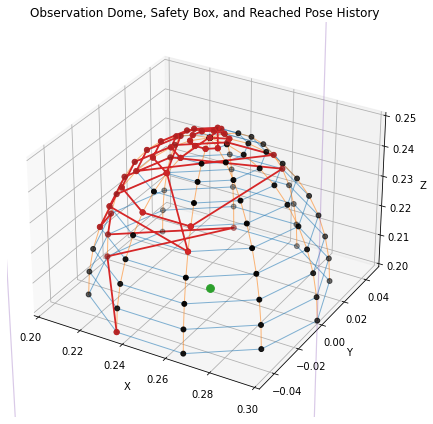

In [5]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

dome_driver.visualize_history(
    ax,
    show_dome=True,
    show_safety_box=True,
    plot_positions_only=True,
    title='Observation Dome, Safety Box, and Reached Pose History',
)

plt.tight_layout()
plt.show()

